<a href="https://colab.research.google.com/github/D010R35/Stats_Projects/blob/main/Weather_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0 Install Module & Load Functions

In [ ]:
!pip install pyod
!pip install shap

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

def feat_plot(model, y1, y2):
  plt.figure(figsize=(6,8))

  plt.subplot(2,1,1)
  model.fit(X, y1)
  res_if = permutation_importance(model, X, y1, n_repeats=10, random_state=42, scoring='accuracy')
  plt.bar(X.columns, res_if.importances_mean)
  plt.xticks(rotation=30)
  plt.title("Feature Importance in Iforest")

  plt.subplot(2,1,2)
  model.fit(X, y2)
  res_lof = permutation_importance(model, X, y2, n_repeats=10, random_state=42, scoring='accuracy')
  plt.bar(X.columns, res_lof.importances_mean)
  plt.xticks(rotation=30)
  plt.title("Feature Importance in LOF")

  plt.tight_layout()
  plt.show()

"""
f_test: Apply F test on two data frame
  A: first df
  B: second df
  A: Text to show in the title
  B: Text to show in the title
"""

import numpy as np
import scipy.stats as stats

def f_test(A, B, nameA, nameB):
  var_A = []
  var_B = []

  for f in A.columns:
    var_A.append(np.var(A[f]))

  for f in B.columns:
    var_B.append(np.var(B[f]))

  fstat = []
  tab = []

  for i in range(len(var_A)):
    if var_A[i] >= var_B[i]:
      fstat.append(var_A[i]/var_B[i])
    else:
      fstat.append(var_B[i]/var_A[i])

  for i in range(len(A.columns)):
    pval = stats.f.sf(fstat[i], len(A)-1, len(B)-1) * 2
    tab.append([A.columns[i], round(pval, 3)])

  print(f"F test on {nameA} vs {nameB}")
  print(tabulate(tab, headers=['Feature', 'p value'], floatfmt=".3f"))

"""
ks_test runs in the same way, we simply changed the specific test used
"""

from tabulate import tabulate
from scipy.stats import ks_2samp

def ks_test(A, B, nameA, nameB):

  tab = []

  for col in range(len(A.columns)):
    stat, pvalue = ks_2samp(A.iloc[:,col], B.iloc[:,col], alternative="two-sided")
    tab.append([A.columns[col], round(pvalue, 3)])

  print(f"KS test on {nameA} vs {nameB}")
  print(tabulate(tab, headers=['Feature', 'p value'], floatfmt=".3f"))

"""
Same for AD test, further specify a method argument, in case permuting is unneccesary
"""

from scipy.stats import anderson_ksamp

def ad_test(A, B, nameA, nameB, method=stats.PermutationMethod()):

  tab = []

  for col in range(len(A.columns)):
    _, _, pval = anderson_ksamp([A.iloc[:,col], B.iloc[:,col]], method=method)
    tab.append([A.columns[col], round(pval, 4)])

  print(f"AD test on {nameA} vs {nameB}")
  print(tabulate(tab, headers=['Feature', 'P Value'], floatfmt=".4f"))

# 1 Anomoly Detection

In [ ]:
# In case ymd are needed
import pandas as pd

df = pd.read_csv("london_weather.csv", parse_dates=["date"])
df = df.set_index("date")
df["year"] = df.index.year
df["month"] = df.index.month
df["day"] = df.index.day

In [ ]:
# Initialize
df["snow_depth"] = df["snow_depth"].fillna(0)
df = df.interpolate(method='linear').iloc[:,:-3]
df = df.ffill().bfill()

# Combine max and min temperature
weather = df.copy()
weather["temp_range"] = weather["max_temp"] - weather["min_temp"]

# Create "snow or not" boolean
snow_mask = weather["snow_depth"] > 0
snow_mask = snow_mask.astype(int)

# Drop the collinear columns
weather = weather.drop(["min_temp", "max_temp", "snow_depth", "global_radiation"], axis=1)

# Deseasonalize by daily
import pandas as pd
Xdeseasoned = pd.DataFrame()
trend = pd.DataFrame()
noise = pd.DataFrame()

from statsmodels.tsa.seasonal import seasonal_decompose
for col in weather.columns:
    decomposition = seasonal_decompose(weather[col], period=365, model='additive', extrapolate_trend='freq')
    Xdeseasoned[col] = decomposition.trend + decomposition.resid
    trend[col] = decomposition.trend
    noise[col] = decomposition.resid

X = Xdeseasoned.ffill().bfill()

# Standardize & Retreive X as DataFrame format
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
scaled = ss.fit_transform(X.values)
X = pd.DataFrame(scaled, index=X.index, columns=X.columns)

# Replace snow_depth with binary label
X["snow"] = snow_mask

In [ ]:
df.corr()

,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
cloud_cover,1.000000,-0.738022,-0.486892,-0.212764,-0.111803,0.048160,0.234908,-0.240991,0.000912
sunshine,-0.738022,1.000000,0.852318,0.472210,0.396902,0.219066,-0.231585,0.226762,-0.033666
global_radiation,-0.486892,0.852318,1.000000,0.691487,0.636133,0.478631,-0.163206,0.150471,-0.061340
max_temp,-0.212764,0.472210,0.691487,1.000000,0.912246,0.810578,-0.071905,0.100348,-0.127989
mean_temp,-0.111803,0.396902,0.636133,0.912246,1.000000,0.955514,-0.010812,0.004821,-0.151361
min_temp,0.048160,0.219066,0.478631,0.810578,0.955514,1.000000,0.037186,-0.074234,-0.154483
precipitation,0.234908,-0.231585,-0.163206,-0.071905,-0.010812,0.037186,1.000000,-0.349463,-0.001369
pressure,-0.240991,0.226762,0.150471,0.100348,0.004821,-0.074234,-0.349463,1.000000,-0.020320
snow_depth,0.000912,-0.033666,-0.061340,-0.127989,-0.151361,-0.154483,-0.001369,-0.020320,1.000000


## 1.0 Correlation

### 1.0.1 Pairplot

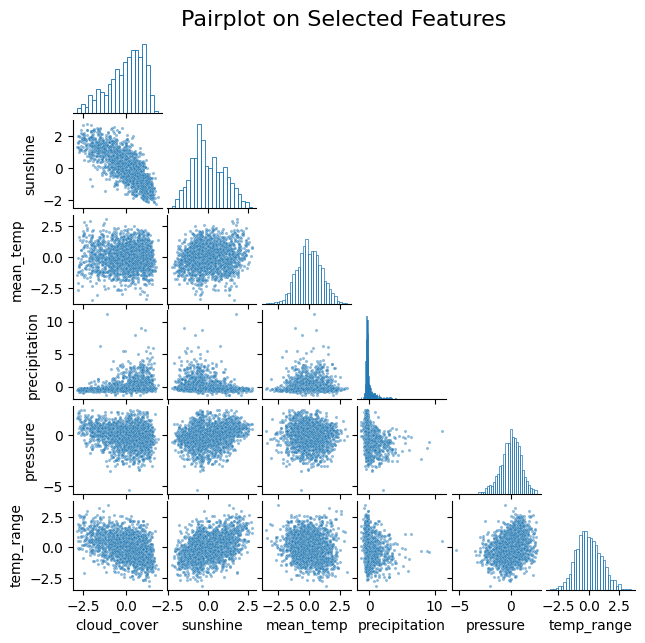

In [ ]:
Xpp = X.sample(2000, random_state=42)
Xpp = Xpp.drop("snow", axis=1)
import seaborn as sns
import matplotlib.pyplot as plt

pairplot = sns.pairplot(Xpp, corner=True,
                        plot_kws={"s": 5, "alpha":0.5},
                        diag_kws=dict(fill=False),
                        dropna=True)
pairplot.fig.suptitle("Pairplot on Selected Features", y=1.01, fontsize=16)
pairplot.fig.set_size_inches(6,6)
plt.show()

### 1.0.2 Chatterjee Corr

In [ ]:
from scipy.stats import chatterjeexi
from itertools import combinations
from tabulate import tabulate
import numpy as np

In [ ]:
pairwise = combinations(X.columns, 2)

tab=[]

for i, j in pairwise:
  feat_i = X[i]
  feat_j = X[j]
  corr, pvalue = chatterjeexi(feat_i, feat_j)
  if np.abs(corr) > 0.4:
    tab.append([i, j, round(corr, 3)])
  else:
    continue

print("Chatterjee Correlation larger than 0.4")
print(tabulate(tab, headers=['Feature A', 'Feature B', 'Chatterjee Corr'], floatfmt=".3f"))

Chatterjee Correlation larger than 0.4
Feature A    Feature B      Chatterjee Corr
-----------  -----------  -----------------
cloud_cover  sunshine                 0.475


## 1.1 Fit Models

In [ ]:
# Fit Iforest
from sklearn.ensemble import IsolationForest
iforest = IsolationForest(
    contamination=0.03,
    n_estimators=150,
    max_samples='auto',
    random_state=42
)
y_if = iforest.fit_predict(X)
y_if = (y_if == -1).astype(int)

X_temp = X.copy()
X_temp['y'] = y_if
X_temp = X_temp[X_temp['y']==1]

df_if = X_temp.drop('y', axis=1)

score_if = iforest.decision_function(X)

# Fit LOF
from pyod.models.lof import LOF
lof = LOF(
    n_neighbors=14,
    contamination=0.03,
    metric='minkowski'
)
lof.fit(X)

y_lof = lof.labels_ == 1
score_lof = lof.predict_proba(X)[:,1]
df_lof = X.loc[y_lof]

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
XPCA = pca.fit_transform(X)

print(f"Variance explainable by PCA: {pca.explained_variance_ratio_[0]:.2%}")

# Fit MAD
from pyod.models.mad import MAD
mad = MAD(threshold=2.5)
mad.fit(XPCA)

y_mad = mad.labels_ == 1
df_mad = X.loc[y_mad]

print(f"Length of MAD outliers: {len(df_mad)}")

# Fit knn
from pyod.models.knn import KNN
knn = KNN(contamination=0.03, n_neighbors=14, n_jobs=-1)
knn.fit(X)

y_knn = knn.labels_ == 1
score_knn = knn.decision_function(X)
df_knn = X.loc[y_knn]

import numpy as np
y_z = np.sum(np.abs(X)>2.17, axis=1) >= 2

df_z = X[y_z]

print(f"Length of Z score outliers: {len(df_z)}")

Variance explainable by PCA: 39.88%
Length of MAD outliers: 146


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Length of Z score outliers: 283


## 1.2 Consensus

In [ ]:
outlier_ind = set()
for df in [df_if, df_lof, df_mad, df_knn, df_z]:
    outlier_ind.update(df.index)

consensus = pd.DataFrame(index=sorted(outlier_ind),
                            columns=['iforest', 'lof', 'mad', 'knn', 'z'])

consensus['iforest'] = consensus.index.isin(df_if.index)
consensus['lof'] = consensus.index.isin(df_lof.index)
consensus['mad'] = consensus.index.isin(df_mad.index)
consensus['knn'] = consensus.index.isin(df_knn.index)
consensus['z'] = consensus.index.isin(df_z.index)

consensus = consensus.astype(int)
consensus['n'] = consensus[['iforest', 'lof', 'mad', 'knn', 'z']].sum(axis=1)

print(f"{len(consensus)} of data ({len(consensus)/len(X):.2%} of the whole data set) are labelled as outliers by any of the algorithms\n")

# Get indices first to prevent overlapping
outlier_ind = set()
for df in [df_if, df_lof, df_knn]:
    outlier_ind.update(df.index)

con3 = pd.DataFrame(index=sorted(outlier_ind),
                            columns=['iforest', 'lof', 'knn'])

con3['iforest'] = con3.index.isin(df_if.index)
con3['lof'] = con3.index.isin(df_lof.index)
con3['knn'] = con3.index.isin(df_knn.index)
con3 = con3.astype(int)

# Set up for both methods = 1
con3['if_lof'] = (con3['iforest'] == con3['lof']) & (con3['iforest'] == 1)
con3['if_knn'] = (con3['iforest'] == con3['knn']) & (con3['iforest'] == 1)
con3['knn_lof'] = (con3['knn'] == con3['lof']) & (con3['knn'] == 1)
con3 = con3.astype(int)
con3['n'] = con3[['iforest', 'lof', 'knn']].sum(axis=1)

from tabulate import tabulate
tab = []
print(f"{len(con3)} of data ({len(con3)/len(X):.2%} of population) are labelled as outliers by any of: [IForest, LOF, kNN]")
print(f"{len(con3[con3['n']==3])} ({len(con3[con3['n']==3])/len(X):.2%} of population) are agreed by all 3 methods\n")

# Set up for either method = 1
if_or_lof = con3['iforest'] + con3['lof'] >= 1
if_or_knn = con3['iforest'] + con3['knn'] >= 1
knn_or_lof = con3['knn'] + con3['lof'] >= 1
agreements = [if_or_lof.sum(), if_or_knn.sum(), knn_or_lof.sum()]

temp = ['if_lof', 'if_knn', 'knn_lof']
for i in temp:
  tab.append([i,
              con3[i].sum(),
              agreements[temp.index(i)],
              f"{con3[i].sum()/agreements[temp.index(i)]:.2%}"])

print(tabulate(tab,
               headers=['Methods', 'Common Count', 'Total Count', 'Proportion of Outliers of the 2 Methods'],
               numalign="center",
               stralign="center"))

1007 of data (6.56% of the whole data set) are labelled as outliers by any of the algorithms

875 of data (5.70% of population) are labelled as outliers by any of: [IForest, LOF, kNN]
106 (0.69% of population) are agreed by all 3 methods

 Methods    Common Count    Total Count    Proportion of Outliers of the 2 Methods
---------  --------------  -------------  -----------------------------------------
 if_lof         142             780                        18.21%
 if_knn         264             658                        40.12%
 knn_lof        208             714                        29.13%


# 2 XAI

## 2.0 Permutation Importance

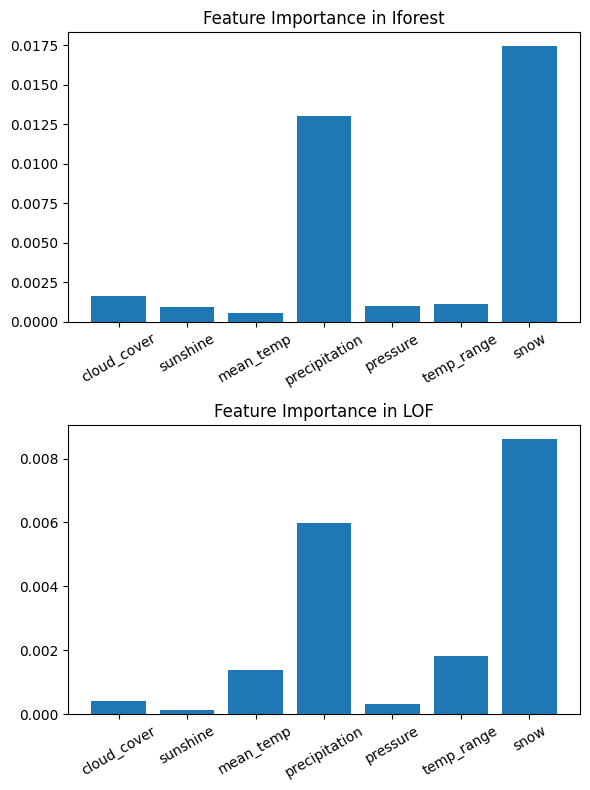

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,
                            max_depth=5,
                            random_state=42)
feat_plot(rf, y_if, y_lof)

## 2.1 IForest

In [ ]:
# This takes around a minute to load
import shap
import numpy as np

tree_explainer = shap.TreeExplainer(iforest)

shap_if = tree_explainer.shap_values(X)
mashap_if = np.abs(shap_if).mean(axis=0)

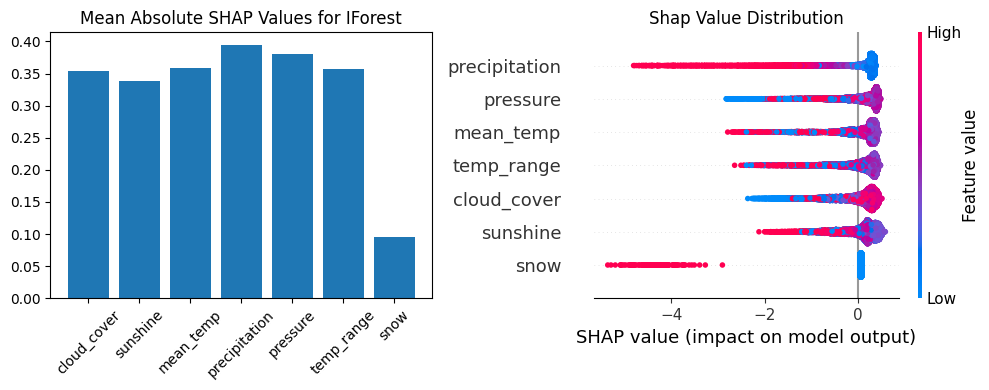

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(X.columns, mashap_if)
plt.title('Mean Absolute SHAP Values for IForest')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
shap.summary_plot(shap_if, X, plot_type="dot", max_display=X.shape[1], plot_size=(10,4), show=False)
plt.title("Shap Value Distribution")

plt.tight_layout()
plt.show()

### 2.1.1 Decision Tree

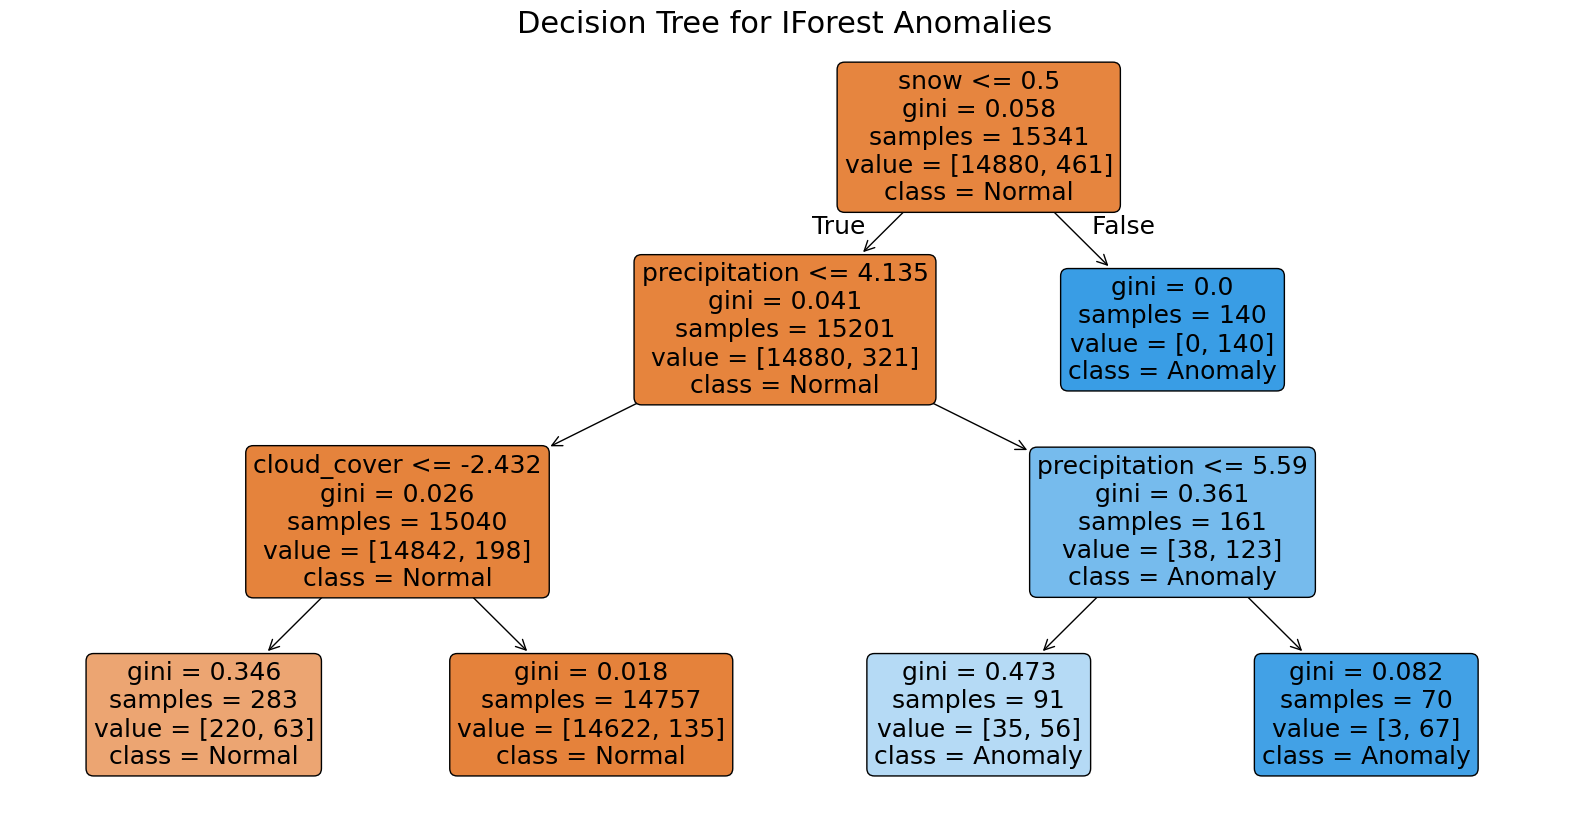

Global Rules for Anomaly Detection:
|--- snow <= 0.50
|   |--- precipitation <= 4.13
|   |   |--- cloud_cover <= -2.43
|   |   |   |--- class: 0
|   |   |--- cloud_cover >  -2.43
|   |   |   |--- class: 0
|   |--- precipitation >  4.13
|   |   |--- precipitation <= 5.59
|   |   |   |--- class: 1
|   |   |--- precipitation >  5.59
|   |   |   |--- class: 1
|--- snow >  0.50
|   |--- class: 1



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

decistree0 = DecisionTreeClassifier(max_depth=3, random_state=42)
decistree0.fit(X, y_if)

plt.figure(figsize=(20, 10))
plot_tree(decistree0,
          feature_names=X.columns,
          class_names=["Normal", "Anomaly"],
          filled=True,
          rounded=True,
          fontsize=18)
plt.title("Decision Tree for IForest Anomalies", fontsize=22)
plt.show()

print("Global Rules for Anomaly Detection:")
print(export_text(decistree0, feature_names=list(X.columns)))

### 2.1.2 Local

In [ ]:
decis_tree_explainer = shap.TreeExplainer(decistree0)
shap_decis = tree_explainer.shap_values(X)
mashap_decis = np.abs(shap_decis).mean(axis=0)

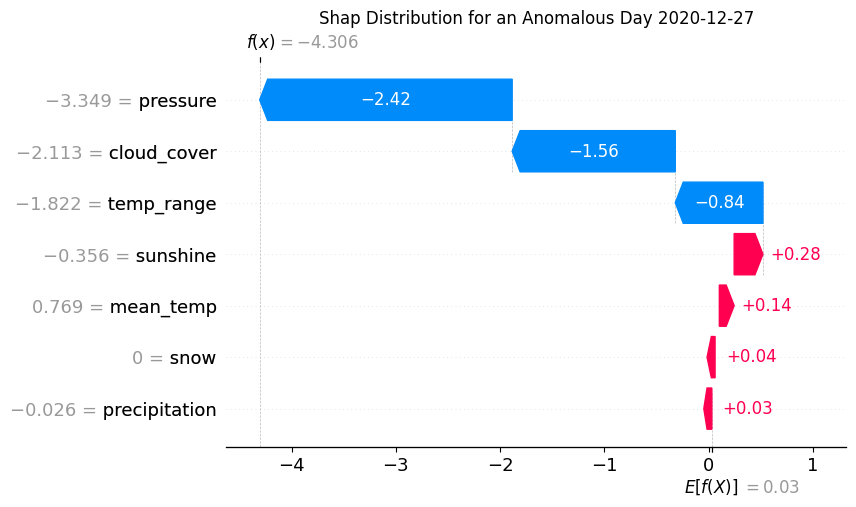

In [ ]:
# Of the 135 un-captured outlier

anom_ind = X.index.get_loc('2020-12-27')
plt.figure(figsize=(6,4))

shap.waterfall_plot(shap.Explanation(values=shap_decis[anom_ind,:],
                    base_values=decis_tree_explainer.expected_value[1],
                    data=X.iloc[anom_ind].values,
                    feature_names=X.columns),
                    show=False)
plt.title(f"Shap Distribution for an Anomalous Day {X.index[anom_ind].date()}")
plt.show()

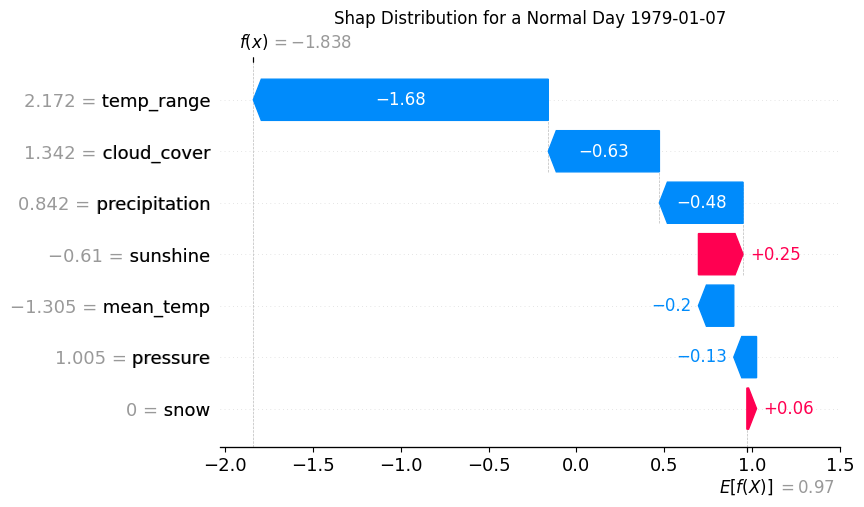

In [ ]:
# Same node, but the normal class

norm_ind = X.index.get_loc('1979-01-07')

shap.waterfall_plot(shap.Explanation(values=shap_if[norm_ind,:],
                    base_values=decis_tree_explainer.expected_value[0],
                    data=X.iloc[norm_ind].values,
                    feature_names=X.columns),
                    show=False)
plt.title(f"Shap Distribution for a Normal Day {X.index[norm_ind].date()}")
plt.show()

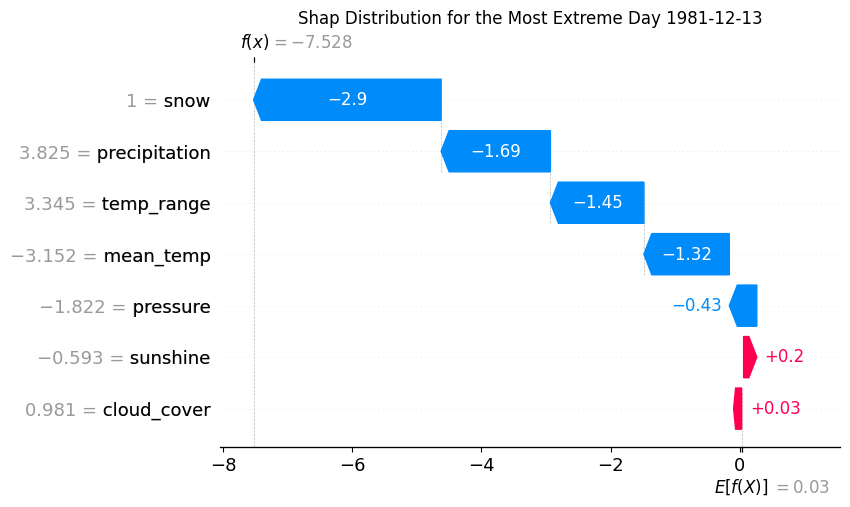

In [ ]:
# Most anomalous day
import matplotlib.pyplot as plt
most_anom_ind = np.argmin(score_if)
shap.waterfall_plot(shap.Explanation(values=shap_decis[most_anom_ind,:],
                    base_values=decis_tree_explainer.expected_value[1],
                    data=X.iloc[most_anom_ind].values,
                    feature_names=X.columns),
                    show=False)
plt.title(f"Shap Distribution for the Most Extreme Day {X.index[most_anom_ind].date()}")
plt.show()

In [ ]:
df = pd.read_csv("london_weather.csv", parse_dates=["date"])
most_snow_ind = np.argmax(df["snow_depth"])
print(df.iloc[most_snow_ind]["date"], df.iloc[most_snow_ind]["snow_depth"])
df.iloc[most_anom_ind]["date"]

1981-12-12 00:00:00 22.0


Timestamp('1981-12-13 00:00:00')

** i.e. Most anomalous day has one of the heaviest snow as well, even we have used a binary label instead

We could suspect correlation, meteorologically, such as with mean temperature

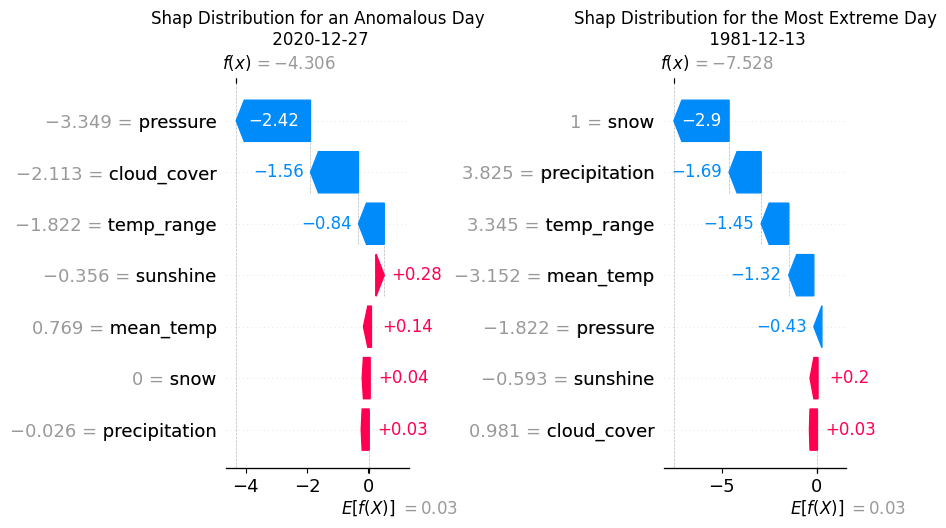

In [ ]:
plt.figure(figsize=(20,4))

plt.subplot(1,3,1)
anom_ind = X.index.get_loc('2020-12-27')
shap.waterfall_plot(shap.Explanation(values=shap_decis[anom_ind,:],
                    base_values=decis_tree_explainer.expected_value[1],
                    data=X.iloc[anom_ind].values,
                    feature_names=X.columns),
                    show=False)
plt.title(f"Shap Distribution for an Anomalous Day\n {X.index[anom_ind].date()}")

plt.subplot(1,3,3)
most_anom_ind = np.argmin(score_if)
shap.waterfall_plot(shap.Explanation(values=shap_decis[most_anom_ind,:],
                    base_values=decis_tree_explainer.expected_value[1],
                    data=X.iloc[most_anom_ind].values,
                    feature_names=X.columns),
                    show=False)
plt.title(f"Shap Distribution for the Most Extreme Day\n {X.index[most_anom_ind].date()}")

plt.show()

### 2.1.3 HP tuning

In [ ]:
from sklearn.ensemble import IsolationForest
from scipy.stats import spearmanr
from tabulate import tabulate
tab = []

mask = pd.DataFrame()

for nest in [100, 400, 600, 800]:
  iforest = IsolationForest(
    contamination=0.02,
    n_estimators=nest,
    max_samples='auto',
    random_state=nest
  )
  iforest.fit(X)
  score_if_hp = iforest.decision_function(X)
  mask[str(nest)] = score_if_hp

mask = mask.astype(float)

for i in [100,400,600,800]:
  corr, p = spearmanr(mask[str(i)], score_if)
  tab.append([i, corr])

print("For Isolation Forest, wrt n_estimator=150:\n")
print(tabulate(tab, headers=['n_estimator', 'Spearman Corr'], floatfmt=".3f"))

For Isolation Forest, wrt n_estimator=150:

  n_estimator    Spearman Corr
-------------  ---------------
          100            0.965
          400            0.980
          600            0.980
          800            0.981


## 2.2 LOF

In [ ]:
# Systematic sampling with interval 7

import shap
import numpy as np

Xsubsample = X.iloc[::7]
print(f"Size of subsample = {len(Xsubsample)} ({len(Xsubsample)/len(X):.2%})")

kernel_explainer = shap.KernelExplainer(lof.predict_proba, shap.kmeans(Xsubsample, 10))

shap_lof = kernel_explainer.shap_values(Xsubsample, n_jobs=-1)
mashap_lof = np.abs(shap_lof[:,:,1]).mean(axis=0)

Size of subsample = 2192 (14.29%)


  0%|          | 0/2192 [00:00<?, ?it/s]

In [ ]:
# Validity of Subsample
ks_test(Xsubsample, X, 'Subsample', 'Whole Data')

KS test on Subsample vs Whole Data
Feature          p value
-------------  ---------
cloud_cover        0.630
sunshine           0.996
mean_temp          0.878
precipitation      0.987
pressure           0.678
temp_range         0.867
snow               1.000


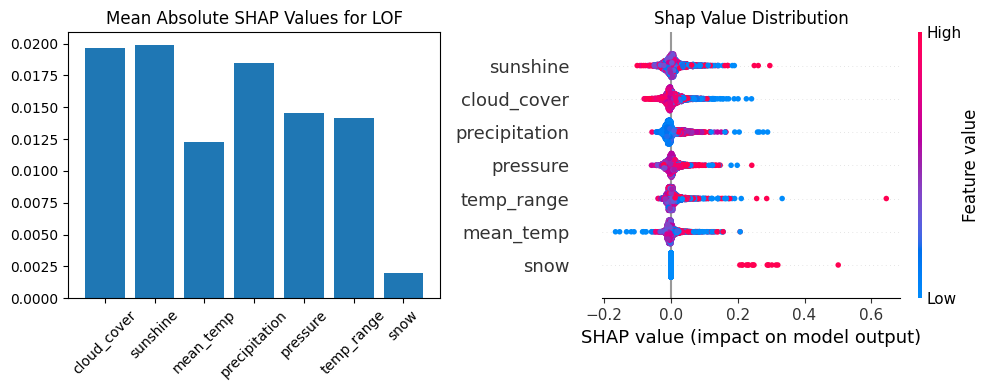

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(Xsubsample.columns, mashap_lof)
plt.title('Mean Absolute SHAP Values for LOF')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
shap.summary_plot(shap_lof[:,:,1], Xsubsample,
                  plot_type="dot", max_display=Xsubsample.shape[1], plot_size=(10,4), show=False)
plt.title("Shap Value Distribution")

plt.tight_layout()
plt.show()

### 2.2.1 HP tuning

In [ ]:
from pyod.models.lof import LOF
from scipy.stats import spearmanr
from tabulate import tabulate
tab = []

mask = pd.DataFrame()

for nneigh in [7, 20, 25, 30]:
  lof = LOF(
    contamination=0.03,
    n_neighbors=nneigh,
    n_jobs=-1
  )
  lof.fit(X)
  score_lof_hp = lof.predict_proba(X)[:,1]
  mask[str(nneigh)] = score_lof_hp

mask = mask.astype(float)

for i in [7, 20, 25, 30]:
  corr, p = spearmanr(mask[str(i)], score_lof)
  tab.append([i, corr])

print("For LOF, wrt n_neighbors=14:\n")
print(tabulate(tab, headers=['n_neighbors', 'Spearman Corr'], floatfmt=".3f"))

For LOF, wrt n_neighbors=14:

  n_neighbors    Spearman Corr
-------------  ---------------
            7            0.837
           20            0.961
           25            0.940
           30            0.924


In [ ]:
from pyod.models.lof import LOF
from scipy.stats import spearmanr
from tabulate import tabulate
import numpy as np
tab = []

mask = pd.DataFrame()

for m in ['euclidean', 'manhattan']:
  lof = LOF(
    contamination=0.03,
    n_neighbors=14,
    metric=m,
    n_jobs=-1
  )
  lof.fit(X)
  score_lof_hp = lof.predict_proba(X)[:,1]
  mask[m] = score_lof_hp

mask = mask.astype(float)

for m in ['euclidean', 'manhattan']:
  corr, p = spearmanr(mask[m], score_lof)
  tab.append([m, corr])

print("For LOF, wrt Minkowski:\n")
print(tabulate(tab, headers=['Metrics', 'Spearman Corr'], floatfmt=".3f"))

For LOF, wrt Minkowski:

Metrics      Spearman Corr
---------  ---------------
euclidean            1.000
manhattan            0.945


# 3 Snow-related Issues

## 3.1 Silhouette Score

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_snow = X[X["snow"]==1]
X_snow = X_snow.drop("snow", axis=1)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_snow)
original_score = silhouette_score(X_snow, kmeans.labels_)

tab = []

for i in range(X_snow.shape[1]):
    X_reduced = np.delete(X_snow, i, axis=1)
    kmeans.fit(X_reduced)
    new_score = silhouette_score(X_reduced, kmeans.labels_)
    impact = original_score - new_score
    tab.append([X_snow.columns[i], round(impact,4)])

print("Impact of Features in Terms of Categorizing Snowy Days:\n")
print(tabulate(tab, headers=['Feature', 'Silhouette Score']))

Impact of Features in Terms of Categorizing Snowy Days:

Feature          Silhouette Score
-------------  ------------------
cloud_cover               -0.0035
sunshine                  -0.0023
mean_temp                 -0.0327
precipitation             -0.0023
pressure                  -0.0486
temp_range                -0.0214


## 3.2 Distribution Tests

In [ ]:
# Snow Outliers vs. Non-snowy Outliers
outlier = df_if.copy()
outlier_snow = outlier[outlier["snow"]==1]
outlier_nosnow = outlier[outlier["snow"]==0]

X_snow = outlier_snow.drop("snow", axis=1)
X_nosnow = outlier_nosnow.drop("snow", axis=1)

ks_test(X_snow, X_nosnow, "Snowy", "Non-snowy Outliers")

KS test on Snowy vs Non-snowy Outliers
Feature          p value
-------------  ---------
cloud_cover        0.000
sunshine           0.000
mean_temp          0.000
precipitation      0.000
pressure           0.028
temp_range         0.000


In [ ]:
# Snowy Days vs. Non-snowy Inliers
#inlier = X[~X.index.isin(df_if.index)]

outlier = df_if.copy()
outlier_snow = outlier[outlier["snow"]==1]

X_snow = outlier_snow.drop("snow", axis=1)
X_nosnow = X[X["snow"]==0][::100]

ad_test(X_snow, X_nosnow, 'Snowy Days', 'Non Snowy Days')

AD test on Snowy Days vs Non Snowy Days
Feature          P Value
-------------  ---------
cloud_cover       0.5291
sunshine          0.0078
mean_temp         0.0001
precipitation     0.4499
pressure          0.0887
temp_range        0.2148


## 3.3 If No Snow

In [ ]:
temp = df_if[df_if["snow"]==1]
X_test_if = temp.copy()
X_test_if["snow"] = 0

y_test_if = iforest.predict(X_test_if)
y_test_if = (y_test_if == -1).astype(int)

X_test_if["y"] = y_test_if

print(f"Length of 'Stubborn' Outliers: {len(X_test_if[X_test_if["y"]==1])}")
X_test_if[X_test_if["y"]==1]

Length of 'Stubborn' Outliers: 4


,cloud_cover,sunshine,mean_temp,precipitation,pressure,temp_range,snow,y
date,,,,,,,,
1981-12-12,-2.004069,1.084347,-3.528990,-0.538261,-0.860832,2.072397,0,1
1981-12-13,0.980922,-0.592707,-3.152033,3.824631,-1.822140,3.344955,0,1
1982-01-14,-2.846226,0.783752,-2.999782,-0.466799,1.042459,2.539634,0,1
1986-02-10,-2.747311,1.362492,-3.275734,-0.383760,1.759313,1.228788,0,1


### 3.3.1 IForest

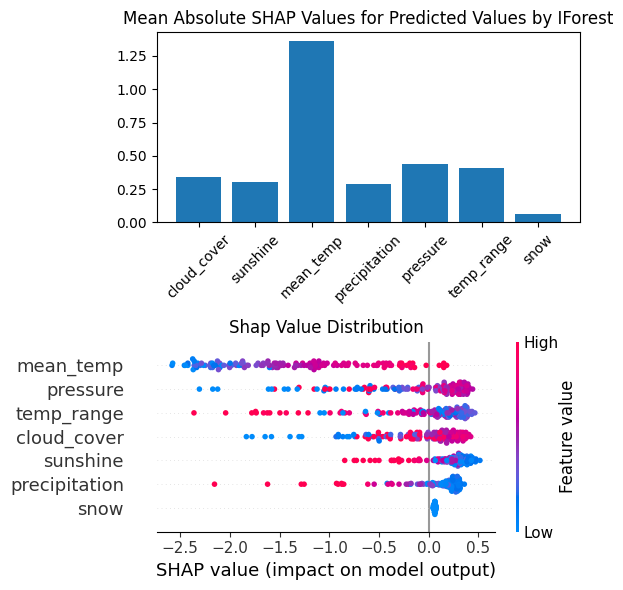

In [ ]:
X_331 = X_test_if.drop("y", axis=1)

shap_test = tree_explainer.shap_values(X_331)
mashap_test = np.abs(shap_test).mean(axis=0)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,12))

plt.subplot(2,1,1)
plt.bar(X_331.columns, mashap_test)
plt.title('Mean Absolute SHAP Values for Predicted Values by IForest')
plt.xticks(rotation=45)

plt.subplot(2,1,2)
shap.summary_plot(shap_test, X_331, plot_type="dot", max_display=X_331.shape[1], plot_size=(6,6), show=False)
plt.title("Shap Value Distribution")

plt.tight_layout()
plt.show()

### 3.3.2 LOF

In [ ]:
ind_temp = df_lof[df_lof["snow"]==1].index

Xtemp = X.copy()
Xtemp['snow'] = 0

lof.fit(Xtemp)
Xtemp['y'] = lof.labels_

X_ifnosnow = Xtemp.loc[ind_temp]
X_ifnosnow

,cloud_cover,sunshine,mean_temp,precipitation,pressure,temp_range,snow,y
date,,,,,,,,
1979-01-01,-1.997606,1.634523,-3.460413,-0.435635,0.459930,1.440978,0,1
1979-01-06,-0.270521,0.534022,-1.918607,-0.615276,1.126277,2.442356,0,0
1979-01-12,-1.277301,1.338468,-1.690542,-0.581752,-0.975618,-0.289882,0,0
1979-01-13,-2.099873,1.370007,-2.574375,-0.530704,0.691454,1.655206,0,0
1979-01-14,0.755843,-0.635731,-1.843615,-0.247330,1.027857,1.911740,0,0
...,...,...,...,...,...,...,...,...
2012-02-11,-2.136629,1.469394,-2.524180,-0.398787,1.800382,1.581951,0,0
2012-02-12,0.730742,-0.893736,-1.949536,-0.307129,1.516637,2.042571,0,0
2013-01-22,-0.078936,-0.594169,-1.886414,-0.295837,-1.398032,0.287153,0,0


In [ ]:
len(X_ifnosnow[X_ifnosnow['y']==1])

18

  0%|          | 0/70 [00:00<?, ?it/s]

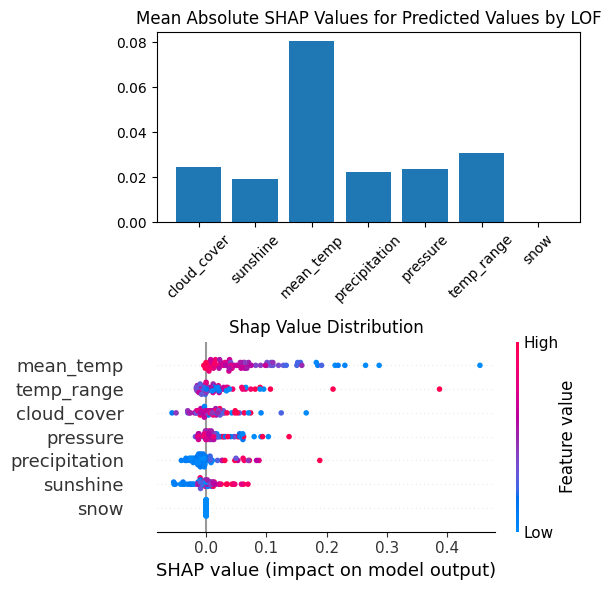

In [ ]:
X_332 = X_ifnosnow.drop("y", axis=1)

shap_test = kernel_explainer.shap_values(X_332)
mashap_test = np.abs(shap_test[:,:,1]).mean(axis=0)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,12))

plt.subplot(2,1,1)
plt.bar(X_332.columns, mashap_test)
plt.title('Mean Absolute SHAP Values for Predicted Values by LOF')
plt.xticks(rotation=45)

plt.subplot(2,1,2)
shap.summary_plot(shap_test[:,:,1], X_332, plot_type="dot", max_display=X_332.shape[1], plot_size=(6,6), show=False)
plt.title("Shap Value Distribution")

plt.tight_layout()
plt.show()

# 4 Time-related Issues

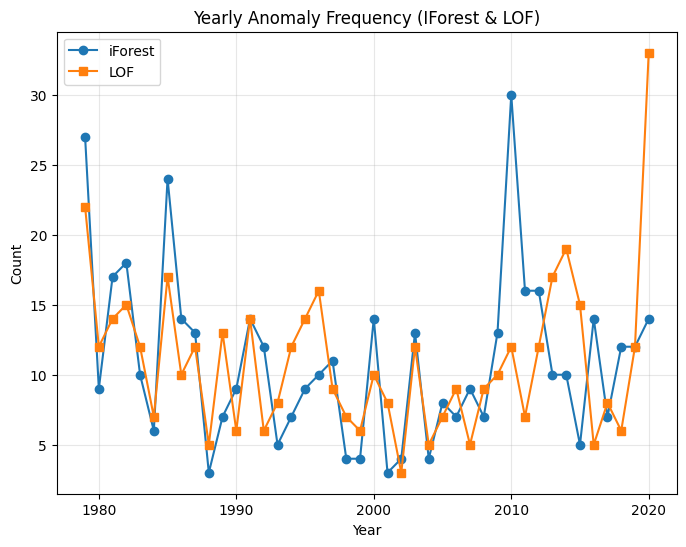

In [ ]:
anom_if = pd.Series(y_if, index=X.index)
yearly_anom_if = anom_if.resample('YE').sum()

anom_lof = pd.Series(y_lof, index=X.index)
yearly_anom_lof = anom_lof.resample('YE').sum()

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))

plt.plot(X.index.year.unique(), yearly_anom_if,
         marker='o', label='iForest')
plt.plot(X.index.year.unique(), yearly_anom_lof,
         marker='s', label='LOF')

plt.title("Yearly Anomaly Frequency (IForest & LOF)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.legend()

#plt.axvline(x=1985.5, color='r')
#plt.axvline(x=2009.5, color='r')

plt.show()

## 4.1 Distribution Tests

In [ ]:
from tabulate import tabulate
from scipy.stats import ks_2samp

tab = []

A_ks = X["1986":"2009"].drop("snow", axis=1)
B_ks = X["2010":"2020"].drop("snow", axis=1)

ks_test(A_ks, B_ks, 'Year 1986 - 2009', 'Year 2010 - 2020')

KS test on Year 1986 - 2009 vs Year 2010 - 2020
Feature          p value
-------------  ---------
cloud_cover        0.000
sunshine           0.000
mean_temp          0.000
precipitation      0.253
pressure           0.031
temp_range         0.007


In [ ]:
ad_test(A_ks, B_ks, 'Year 1986 - 2009', 'Year 2010 - 2020', method=None)

AD test on Year 1986 - 2009 vs Year 2010 - 2020
Feature          P Value
-------------  ---------
cloud_cover       0.0010
sunshine          0.0010
mean_temp         0.0010
precipitation     0.1491
pressure          0.0312
temp_range        0.0026


/tmp/ipython-input-1188699775.py:90: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  _, _, pval = anderson_ksamp([A.iloc[:,col], B.iloc[:,col]], method=method)


## 4.2 Shap

### 4.2.1 IForest

In [ ]:
import shap
import numpy as np

A = X["1987":"2009"]
B = X["2010":"2020"]

shap_A_if = tree_explainer.shap_values(A)
mashap_A_if = np.abs(shap_A_if).mean(axis=0)

shap_B_if = tree_explainer.shap_values(B)
mashap_B_if = np.abs(shap_B_if).mean(axis=0)

In [ ]:
from scipy.stats import spearmanr
corr, p = spearmanr(mashap_A_if, mashap_B_if)
print(f"Spearman Corr = {round(corr,3)}")

Spearman Corr = 0.357


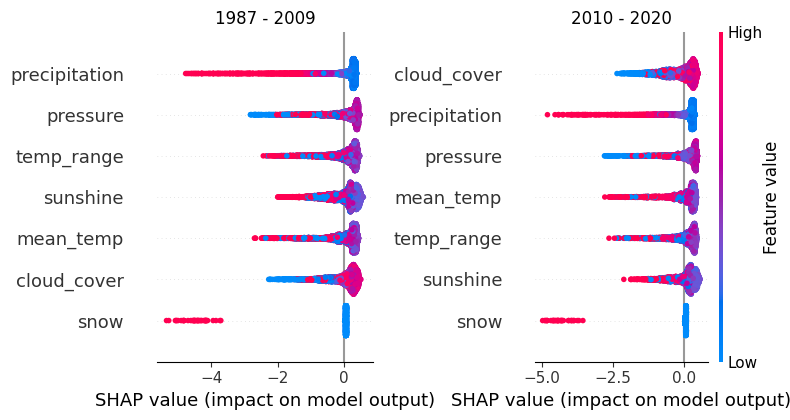

In [ ]:
import matplotlib.pyplot as plt

plt.subplot(1,2,1)
shap.summary_plot(shap_A_if, A, plot_type="dot", show=False, color_bar=False)
plt.title("1987 - 2009")

plt.subplot(1,2,2)
shap.summary_plot(shap_B_if, B, plot_type="dot", show=False)
plt.title("2010 - 2020")

plt.tight_layout()
plt.show()

### 4.2.2 LOF

In [ ]:
import shap
import numpy as np

A_temp = X["1987":"2009"]
A = A_temp[::4]
B_temp = X["2010":"2020"]
B = B_temp[::2]

shap_A_lof = kernel_explainer.shap_values(A)
mashap_A_lof = np.abs(shap_A_lof).mean(axis=0)

shap_B_lof = kernel_explainer.shap_values(B)
mashap_B_lof = np.abs(shap_B_lof).mean(axis=0)

  0%|          | 0/2101 [00:00<?, ?it/s]

  0%|          | 0/2009 [00:00<?, ?it/s]

In [ ]:
from scipy.stats import spearmanr
corr, p = spearmanr(mashap_A_lof[:,1], mashap_B_lof[:,1])
print(f"Spearman Corr = {round(corr,3)}")

Spearman Corr = 0.857


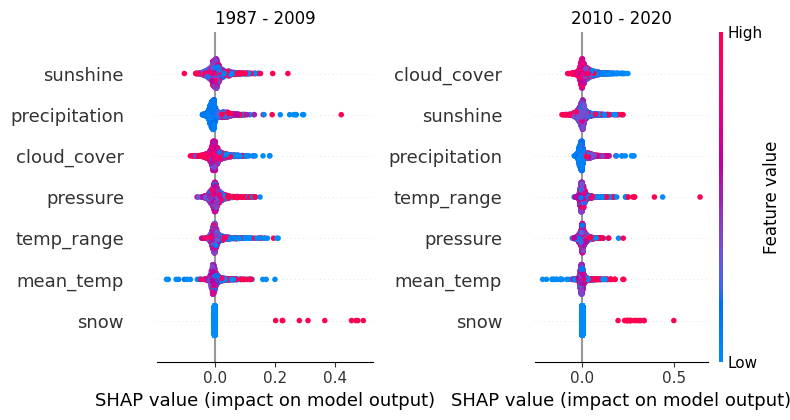

In [ ]:
import matplotlib.pyplot as plt

plt.subplot(1,2,1)
shap.summary_plot(shap_A_lof[:,:,1], A, plot_type="dot", show=False, color_bar=False)
plt.title("1987 - 2009")

plt.subplot(1,2,2)
shap.summary_plot(shap_B_lof[:,:,1], B, plot_type="dot", show=False)
plt.title("2010 - 2020")

plt.tight_layout()
plt.show()

# 5 Regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV

def ridge_reg(X, y, degree=6):
  poly = PolynomialFeatures(degree=degree, include_bias=False, interaction_only=True)
  X_poly = poly.fit_transform(X)

  ridge = RidgeCV(cv=5)
  ridge.fit(X_poly, y)

  ridge_df = pd.DataFrame({
    'feature': poly.get_feature_names_out(X.columns),
    'coef': ridge.coef_,
    'abs_coef': np.abs(ridge.coef_)
  })

  return ridge_df.sort_values('abs_coef', ascending=False)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

def logis_reg(X, y, degree=6):
  poly = PolynomialFeatures(degree=degree, include_bias=False, interaction_only=True)
  X_poly = poly.fit_transform(X)

  logis = LogisticRegression(random_state=42,
                             solver='saga', max_iter=5000,
                             penalty='l2', n_jobs=-1)
  logis.fit(X_poly, y)

  logis_df = pd.DataFrame({
    'feature': poly.get_feature_names_out(X.columns),
    'coef': logis.coef_[0],
    'abs_coef': np.abs(logis.coef_[0])
  })

  return logis_df.sort_values('abs_coef', ascending=False)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LassoCV

def lasso_reg(X, y, degree=6):
  poly = PolynomialFeatures(degree=degree, include_bias=False, interaction_only=True)
  X_poly = poly.fit_transform(X)

  lasso = LassoCV(cv=5, max_iter=10000)
  lasso.fit(X_poly, y)

  lasso_df = pd.DataFrame({
    'feature': poly.get_feature_names_out(X.columns),
    'coef': lasso.coef_,
    'abs_coef': np.abs(lasso.coef_)
  })

  return lasso_df.sort_values('abs_coef', ascending=False)

## 5.1 Whole Data

In [ ]:
lasso_reg(X, score_if*100, degree=2).head(10)

,feature,coef,abs_coef
6,snow,-16.080242,16.080242
21,mean_temp snow,1.827811,1.827811
3,precipitation,-1.646002,1.646002
7,cloud_cover sunshine,1.423868,1.423868
13,sunshine mean_temp,-1.192023,1.192023
24,precipitation snow,0.979862,0.979862
27,temp_range snow,0.801168,0.801168
20,mean_temp temp_range,0.711106,0.711106
22,precipitation pressure,0.586744,0.586744
0,cloud_cover,0.532772,0.532772


In [ ]:
logis_reg(X[::7], y_if[::7], degree=2).head(5)

,feature,coef,abs_coef
21,mean_temp snow,-3.166263,3.166263
6,snow,2.205273,2.205273
3,precipitation,1.297683,1.297683
2,mean_temp,-1.074533,1.074533
0,cloud_cover,-1.007902,1.007902


## 5.2 Non-snowy Days

In [ ]:
Xmerge = X.copy()
Xmerge["score"] = score_if*100

X_nosnow = Xmerge[Xmerge["snow"]==0]
y_nosnow = X_nosnow["score"]
X_nosnow = X_nosnow.drop(["snow", "score"], axis=1)

lasso_reg(X_nosnow, y_nosnow, degree=2).head(5)

,feature,coef,abs_coef
3,precipitation,-1.610603,1.610603
6,cloud_cover sunshine,1.393367,1.393367
11,sunshine mean_temp,-1.090377,1.090377
17,mean_temp temp_range,0.699800,0.699800
18,precipitation pressure,0.560805,0.560805


** i.e. Precipitation, cloud+sunshine, mean_temp+sunshin are top 3 most important

In [ ]:
Xmerge = X.copy()
Xmerge["y"] = y_if

X_nosnow = Xmerge[Xmerge["snow"]==0]
y_nosnow = X_nosnow["y"]
X_nosnow = X_nosnow.drop(["snow", "y"], axis=1)

logis_reg(X_nosnow[::7], y_nosnow[::7], degree=2).head(5)

,feature,coef,abs_coef
3,precipitation,1.765342,1.765342
11,sunshine mean_temp,1.466202,1.466202
0,cloud_cover,-1.434282,1.434282
6,cloud_cover sunshine,-0.851562,0.851562
17,mean_temp temp_range,-0.779534,0.779534


### 5.2.1 Snow

In [ ]:
Xmerge = X.copy()
Xmerge["score"] = score_if*100

X_snow = Xmerge[Xmerge["snow"]==1]
y_snow = X_snow["score"]
X_snow = X_snow.drop(["snow", "score"], axis=1)

ridge_reg(X_snow, y_snow, degree=2).head(10)

,feature,coef,abs_coef
1,sunshine,-2.169579,2.169579
0,cloud_cover,-1.778436,1.778436
2,mean_temp,1.620676,1.620676
8,cloud_cover precipitation,-1.617376,1.617376
5,temp_range,-1.312561,1.312561
12,sunshine precipitation,-1.305084,1.305084
6,cloud_cover sunshine,0.970104,0.970104
11,sunshine mean_temp,-0.902753,0.902753
13,sunshine pressure,0.769286,0.769286
7,cloud_cover mean_temp,-0.657841,0.657841


In [ ]:
Xmerge = X.copy()
Xmerge["score"] = score_if*100

X_snow = Xmerge[Xmerge["snow"]==1]
y_snow = X_snow["score"]
X_snow = X_snow.drop(["snow", "score"], axis=1)

lasso_reg(X_snow, y_snow, degree=2).head(10)

,feature,coef,abs_coef
2,mean_temp,1.100938,1.100938
6,cloud_cover sunshine,0.793822,0.793822
8,cloud_cover precipitation,-0.341946,0.341946
17,mean_temp temp_range,0.327960,0.327960
18,precipitation pressure,0.252886,0.252886
19,precipitation temp_range,-0.145956,0.145956
20,pressure temp_range,-0.094661,0.094661
16,mean_temp pressure,-0.060123,0.060123
4,pressure,0.058228,0.058228
14,sunshine temp_range,0.037249,0.037249


## 5.3 Two time periods

In [ ]:
Xmerge = X.copy()
Xmerge["y"] = y_if
Xmerge["score"] = score_if

y_A = Xmerge["1986":"2009"]
y_A = y_A["y"]
y_B = Xmerge["2010":"2020"]
y_B = y_B["y"]

score_A = Xmerge["1986":"2009"]
score_A = score_A["score"]
score_B = Xmerge["2010":"2020"]
score_B = score_B["score"]

X_A = Xmerge["1986":"2009"].drop(["y", "score"], axis=1)
X_B = Xmerge["2010":"2020"].drop(["y", "score"], axis=1)

In [ ]:
ridge_reg(X_A, score_A).head(10)

,feature,coef,abs_coef
6,snow,-0.129148,0.129148
41,cloud_cover pressure snow,0.039091,0.039091
21,mean_temp snow,0.036523,0.036523
32,cloud_cover sunshine snow,0.026805,0.026805
66,cloud_cover sunshine mean_temp snow,0.021565,0.021565
24,precipitation snow,0.021561,0.021561
88,sunshine mean_temp temp_range snow,0.020322,0.020322
111,cloud_cover mean_temp pressure temp_range snow,-0.019860,0.019860
62,pressure temp_range snow,0.019017,0.019017
46,sunshine mean_temp snow,0.018487,0.018487


In [ ]:
ridge_reg(X_B, score_B).head(10)

,feature,coef,abs_coef
6,snow,-0.069250,0.069250
21,mean_temp snow,0.062290,0.062290
12,cloud_cover snow,-0.029224,0.029224
17,sunshine snow,0.021060,0.021060
55,mean_temp precipitation snow,-0.017863,0.017863
3,precipitation,-0.016683,0.016683
32,cloud_cover sunshine snow,0.016265,0.016265
103,cloud_cover sunshine mean_temp temp_range snow,-0.016144,0.016144
66,cloud_cover sunshine mean_temp snow,0.015363,0.015363
24,precipitation snow,0.014362,0.014362


In [ ]:
logis_reg(X_A[::4], y_A[::4]).head(10)

,feature,coef,abs_coef
21,mean_temp snow,-1.956930,1.956930
6,snow,1.192944,1.192944
66,cloud_cover sunshine mean_temp snow,0.674622,0.674622
2,mean_temp,-0.668412,0.668412
119,cloud_cover sunshine mean_temp precipitation p...,0.627018,0.627018
70,cloud_cover sunshine pressure temp_range,-0.578312,0.578312
3,precipitation,0.576148,0.576148
33,cloud_cover mean_temp precipitation,-0.573581,0.573581
0,cloud_cover,-0.551715,0.551715
63,cloud_cover sunshine mean_temp precipitation,-0.507377,0.507377


In [ ]:
logis_reg(X_B[::2], y_B[::2]).head(10)

,feature,coef,abs_coef
21,mean_temp snow,-2.171273,2.171273
6,snow,1.187603,1.187603
2,mean_temp,-0.897611,0.897611
34,cloud_cover mean_temp pressure,0.860188,0.860188
20,mean_temp temp_range,-0.857888,0.857888
108,cloud_cover mean_temp precipitation pressure t...,-0.855652,0.855652
29,cloud_cover sunshine precipitation,-0.845280,0.845280
66,cloud_cover sunshine mean_temp snow,0.773249,0.773249
25,pressure temp_range,-0.600588,0.600588
32,cloud_cover sunshine snow,-0.516693,0.516693
